#  AI-Powered Helpdesk Automation System
## Model Team – Official Training Notebook
---

We are building:

1️⃣ MODEL 1 – Multi-Task Classification  
2️⃣ MODEL 2 – Named Entity Recognition (NER)  
3️⃣ MODEL 3 – Duplicate Detection  

Additionally, we implement preprocessing modules:
- Text Normalization
- Translation
- OCR
- Language Detection


## 1. Environment Setup

Installing required libraries for:

- Data processing
- Transformer training
- Evaluation
- Sentence embeddings
- OCR
- API integration

In [ ]:
# SECTION 1: Environment Setup

# Core NLP & Transformers
!pip install -q transformers datasets seqeval sentence-transformers

# ML utilities
!pip install -q scikit-learn

# OCR
!pip install -q pytesseract easyocr

# If using Tesseract OCR (Colab Linux setup)
!apt-get install -y tesseract-ocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 19.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


## 2. Import Libraries

Libraries used:

- pandas, numpy
- scikit-learn
- torch
- transformers
- datasets
- seqeval
- sentence-transformers

In [ ]:
# SECTION 2: Import Libraries

import pandas as pd
import numpy as np
import torch
import json
import re
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    DistilBertForTokenClassification,
    Trainer,
    TrainingArguments
)

# HuggingFace Dataset
from datasets import Dataset

# NER Evaluation
from seqeval.metrics import classification_report as ner_classification_report

# Duplicate Detection
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# OCR
import pytesseract
import easyocr

# Device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Load Dataset

Main Dataset Columns:
- user_input_text
- category
- sub_category
- priority
- auto_resolve
- assigned_team

NER Dataset:
- BIO formatted JSON
- Token-level entity labels

In [ ]:
import pandas as pd
import numpy as np
import torch
import json
import re
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    DistilBertForTokenClassification,
    Trainer,
    TrainingArguments
)

# HuggingFace Dataset
from datasets import Dataset

# NER Evaluation
from seqeval.metrics import classification_report as ner_classification_report

# Duplicate Detection
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# OCR
import pytesseract
import easyocr

# Device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



# SECTION 3: Load Dataset


df = pd.read_csv("Final_Balanced_10000_IT_Support_Tickets.csv")

print("Dataset Loaded Successfully ")
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nSample Data:")
display(df.head())
# Remove completely empty rows
df.dropna(subset=["user_input_text"], inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("After cleaning shape:", df.shape)
# Create label encodings for multi-task model

from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()
priority_encoder = LabelEncoder()
subcat_encoder = LabelEncoder()
auto_encoder = LabelEncoder()

df["category_label"] = category_encoder.fit_transform(df["category"])
df["priority_label"] = priority_encoder.fit_transform(df["Priority"])
df["sub_category_label"] = subcat_encoder.fit_transform(df["sub_category"])
df["auto_resolve_label"] = auto_encoder.fit_transform(df["auto_resolve"])

print("Labels encoded successfully ✅")
# Load NER annotation file
with open("ner_annotations_enhanced.json", "r") as f:
    ner_data = json.load(f)

print("NER dataset loaded ✅")
print("Total NER samples:", ner_data["metadata"]["total_samples"])
print("Entity types:", ner_data["metadata"]["entity_types"])

Using device: cuda
Dataset Loaded Successfully 
Shape: (10000, 6)

Columns: Index(['user_input_text', 'Priority', 'category', 'sub_category',
       'auto_resolve', 'assigned_team'],
      dtype='object')

Sample Data:


,user_input_text,Priority,category,sub_category,auto_resolve,assigned_team
0,I am experiencing an issue with the investment...,medium,Network,Network Connectivity,False,Network Support
1,I am reaching out to learn more about the scal...,medium,Software,Software Support,False,Application Support
2,Currently experiencing i am writing to request...,medium,Access,Access Request,True,IAM Support
3,I am writing to inquire about the integrations...,medium,Software,Software Support,False,Application Support
4,I am reporting an issue with the marketing age...,medium,Software,Software Support,False,Application Support


After cleaning shape: (10000, 6)
Labels encoded successfully ✅
NER dataset loaded ✅
Total NER samples: 680
Entity types: ['APP_NAME', 'ERROR_CODE', 'DEVICE_NAME', 'USERNAME', 'NETWORK_NAME', 'TIME', 'ACTION', 'PRIORITY']


## 4. Data Validation

We perform:

- Dataset shape check
- Null value detection
- Duplicate removal
- Category distribution check
- Priority distribution check
- Sub-category consistency
- Text length analysis
- Data leakage check

In [ ]:
# Dataset shape check
print("Dataset Shape:", df.shape)
# NUll value detection
print(df.isnull().sum())
# Duplicate removal
print("Duplicate_count:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
# Category Distribution Check
print(df["category"].value_counts())
# Priority Distribution Check
print(df["Priority"].value_counts())
# Sub-category consistency
print(df)

Dataset Shape: (10000, 10)
user_input_text       0
Priority              0
category              0
sub_category          0
auto_resolve          0
assigned_team         0
category_label        0
priority_label        0
sub_category_label    0
auto_resolve_label    0
dtype: int64
Duplicate_count: 0
category
Network     2500
Software    2500
Access      2500
Hardware    2500
Name: count, dtype: int64
Priority
high      5302
medium    3808
low        890
Name: count, dtype: int64
                                        user_input_text Priority  category  \
0     I am experiencing an issue with the investment...   medium   Network   
1     I am reaching out to learn more about the scal...   medium  Software   
2     Currently experiencing i am writing to request...   medium    Access   
3     I am writing to inquire about the integrations...   medium  Software   
4     I am reporting an issue with the marketing age...   medium  Software   
...                                               

## 5. Preprocessing Pipeline

Before model training, text goes through:

1. Text Normalization
2. Language Detection
3. Transliteration (if needed)
4. Translation (if needed)
5. OCR text merge (if screenshot provided)

This ensures consistent input for all models.

In [ ]:
def clean_text(text):
    text = str(text)
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Reduce repeated characters (heyyyy → heyy)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    return text

df["clean_text"] = df["user_input_text"].apply(clean_text)

df[["user_input_text", "clean_text"]].head()

,user_input_text,clean_text
0,I am experiencing an issue with the investment...,i am experiencing an issue with the investment...
1,I am reaching out to learn more about the scal...,i am reaching out to learn more about the scal...
2,Currently experiencing i am writing to request...,currently experiencing i am writing to request...
3,I am writing to inquire about the integrations...,i am writing to inquire about the integrations...
4,I am reporting an issue with the marketing age...,i am reporting an issue with the marketing age...


## 6. Train-Test Split

We use stratified split:

- 80% Training
- 20% Testing

Stratification is based on category to maintain class balance.

In [ ]:
category_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

df["category_label"] = category_encoder.fit_transform(df["category"])
df["Priority_label"] = priority_encoder.fit_transform(df["Priority"])

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["category_label"]
)

print("Train Size:", train_df.shape)
print("Test Size:", test_df.shape)

Train Size: (8000, 12)
Test Size: (2000, 12)


## 7. Baseline Models (TF-IDF + Logistic Regression)

Baseline models are built for:

- Category
- Priority
- Sub-category (optional)

Purpose:

- Establish performance benchmark
- Compare with transformer-based models
- Measure improvement

In [ ]:
X_train = train_df["clean_text"]
X_test = test_df["clean_text"]

y_train = train_df["category_label"]
y_test = test_df["category_label"]

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)  # Unigrams + Bigrams
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)

TF-IDF Shape: (8000, 10000)


In [ ]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = baseline_model.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=category_encoder.classes_))

Accuracy: 0.947

Classification Report:

              precision    recall  f1-score   support

      Access       0.92      0.94      0.93       500
    Hardware       0.99      1.00      1.00       500
     Network       0.98      0.91      0.94       500
    Software       0.90      0.94      0.92       500

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



## 8. MODEL 1 – Multi-Task Classification Model

Model Used:
distilbert-base-uncased

Architecture:
Shared encoder + multiple classification heads

The model predicts:

- category
- sub_category
- priority
- auto_resolve
- ticket_summary

This is a single transformer model with multiple outputs.

In [ ]:
from datasets import Dataset

multi_train_dataset = Dataset.from_pandas(
    train_df[["clean_text", "category_label", "priority_label"]]
)

multi_test_dataset = Dataset.from_pandas(
    test_df[["clean_text", "category_label", "priority_label"]]
)

In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

multi_train_dataset = multi_train_dataset.map(tokenize_function, batched=True)
multi_test_dataset = multi_test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
import torch
from torch import nn
from transformers import DistilBertModel

class MultiTaskDistilBERT(nn.Module):
    def __init__(self, num_categories, num_priorities):
        super(MultiTaskDistilBERT, self).__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        hidden_size = self.bert.config.hidden_size

        self.dropout = nn.Dropout(0.3)

        # Two heads
        self.category_classifier = nn.Linear(hidden_size, num_categories)
        self.priority_classifier = nn.Linear(hidden_size, num_priorities)

    def forward(self, input_ids, attention_mask, category_labels=None, priority_labels=None):

        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # CLS token

        pooled_output = self.dropout(pooled_output)

        category_logits = self.category_classifier(pooled_output)
        priority_logits = self.priority_classifier(pooled_output)

        loss = None

        if category_labels is not None and priority_labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            category_loss = loss_fct(category_logits, category_labels)
            priority_loss = loss_fct(priority_logits, priority_labels)
            loss = category_loss + priority_loss

        return {
            "loss": loss,
            "category_logits": category_logits,
            "priority_logits": priority_logits
        }

In [ ]:
multi_train_dataset = multi_train_dataset.rename_column("category_label", "category_labels")
multi_train_dataset = multi_train_dataset.rename_column("priority_label", "priority_labels")

multi_test_dataset = multi_test_dataset.rename_column("category_label", "category_labels")
multi_test_dataset = multi_test_dataset.rename_column("priority_label", "priority_labels")

multi_train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "category_labels", "priority_labels"]
)

multi_test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "category_labels", "priority_labels"]
)

In [ ]:
num_categories = len(category_encoder.classes_)
num_priorities = len(priority_encoder.classes_)

multi_model = MultiTaskDistilBERT(
    num_categories=num_categories,
    num_priorities=num_priorities
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./multi_task_results",
    eval_strategy="epoch", # Changed from evaluation_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

def compute_metrics(eval_pred):
    category_logits, priority_logits = eval_pred.predictions
    category_preds = category_logits.argmax(axis=-1)
    priority_preds = priority_logits.argmax(axis=-1)

    category_acc = (category_preds == eval_pred.label_ids[0]).mean()
    priority_acc = (priority_preds == eval_pred.label_ids[1]).mean()

    return {
        "category_accuracy": category_acc,
        "priority_accuracy": priority_acc
    }

trainer = Trainer(
    model=multi_model,
    args=training_args,
    train_dataset=multi_train_dataset,
    eval_dataset=multi_test_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.257159,0.823087
2,0.772615,0.718518
3,0.632754,0.669656


TrainOutput(global_step=1500, training_loss=0.8875095011393229, metrics={'train_runtime': 318.4857, 'train_samples_per_second': 75.357, 'train_steps_per_second': 4.71, 'total_flos': 0.0, 'train_loss': 0.8875095011393229, 'epoch': 3.0})

## 9. MODEL 2 – Named Entity Recognition (NER)

Model Type:
DistilBERT for Token Classification

Annotation Format:
BIO tagging

Entities Extracted:

- DEVICE_NAME
- ERROR_CODE
- USERNAME
- NETWORK_NAME
- APP_NAME
- TIME
- ACTION
- PRIORITY

Evaluation Metrics:
- Precision
- Recall
- F1 per entity

In [ ]:
import json

with open("ner_annotations_enhanced.json", "r") as f:
    ner_data = json.load(f)

print("Total Samples:", len(ner_data["annotations"]))

Total Samples: 580


In [ ]:
label_list = set()

for sample in ner_data["annotations"]:
    for token in sample["tokens"]:
        label_list.add(token["label"])

label_list = sorted(list(label_list))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print("NER Labels:", label_list)

NER Labels: ['B-ACTION', 'B-APP_NAME', 'B-DEVICE_NAME', 'B-ERROR_CODE', 'B-NETWORK_NAME', 'B-PRIORITY', 'B-TIME', 'B-USERNAME', 'I-APP_NAME', 'I-ERROR_CODE', 'I-NETWORK_NAME', 'I-TIME', 'O']


In [ ]:
from datasets import Dataset

ner_samples = []

for sample in ner_data["annotations"]:
    tokens = [t["token"] for t in sample["tokens"]]
    labels = [label2id[t["label"]] for t in sample["tokens"]]

    ner_samples.append({
        "tokens": tokens,
        "ner_tags": labels
    })

ner_dataset = Dataset.from_list(ner_samples)

In [ ]:
ner_dataset = ner_dataset.train_test_split(test_size=0.2, seed=42)

train_ner = ner_dataset["train"]
test_ner = ner_dataset["test"]

In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=128
    )

    labels = []

    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

train_ner = train_ner.map(tokenize_and_align_labels, batched=True)
test_ner = test_ner.map(tokenize_and_align_labels, batched=True)

train_ner.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ner.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/464 [00:00<?, ? examples/s]

Map:   0%|          | 0/116 [00:00<?, ? examples/s]

In [ ]:
from transformers import DistilBertForTokenClassification

ner_model = DistilBertForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

ner_training_args = TrainingArguments(
    output_dir="./ner_results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

ner_trainer = Trainer(
    model=ner_model,
    args=ner_training_args,
    train_dataset=train_ner,
    eval_dataset=test_ner
)

ner_trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.579241
2,No log,0.215803
3,No log,0.151391


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=87, training_loss=0.5770651280194864, metrics={'train_runtime': 24.3574, 'train_samples_per_second': 57.149, 'train_steps_per_second': 3.572, 'total_flos': 45476321955840.0, 'train_loss': 0.5770651280194864, 'epoch': 3.0})

In [ ]:
ner_trainer.evaluate()

{'eval_loss': 0.15139131247997284,
 'eval_runtime': 0.4901,
 'eval_samples_per_second': 236.705,
 'eval_steps_per_second': 16.324,
 'epoch': 3.0}

## 10. MODEL 3 – Duplicate Detection

Model Used:
sentence-transformers/all-MiniLM-L6-v2

Method:

1. Generate sentence embeddings
2. Compute cosine similarity
3. Apply threshold logic
4. Return duplicate_ticket_id if similarity exceeds threshold

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Reuse TF-IDF vectorizer from baseline
existing_vectors = tfidf.transform(df["clean_text"])

def check_duplicate(new_text, threshold=0.85):
    new_vector = tfidf.transform([clean_text(new_text)])

    similarities = cosine_similarity(new_vector, existing_vectors)
    max_similarity = similarities.max()

    if max_similarity > threshold:
        return True, float(max_similarity)
    else:
        return False, float(max_similarity)

In [ ]:
is_dup, score = check_duplicate("Laptop not connecting to wifi since morning")

print("Duplicate:", is_dup)
print("Similarity Score:", score)

Duplicate: False
Similarity Score: 0.17902721453729883


## 11. Unified Prediction Pipeline

Function:
predict_ticket(text, image=None)

Steps inside function:

1. Normalize text
2. Detect language
3. Translate if required
4. Apply OCR (if image provided)
5. Merge OCR text
6. Run MODEL 1
7. Run MODEL 2
8. Run MODEL 3
9. Apply backend decision logic
10. Return structured JSON

In [ ]:
multi_model.eval()
ner_model.eval()

DistilBertForTokenClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
   

In [ ]:
def generate_ticket(text):

    # Step 1: Clean text
    cleaned = clean_text(text)

    # Step 2: Duplicate check
    is_duplicate, similarity = check_duplicate(cleaned)

    # Step 3: Tokenize for classification
    inputs = tokenizer(cleaned, return_tensors="pt", truncation=True, padding=True, max_length=128)

    with torch.no_grad():
        outputs = multi_model(**inputs)

    category_pred = torch.argmax(outputs["category_logits"], dim=1).item()
    priority_pred = torch.argmax(outputs["priority_logits"], dim=1).item()

    category = category_encoder.inverse_transform([category_pred])[0]
    priority = priority_encoder.inverse_transform([priority_pred])[0]

    # Step 4: NER Prediction
    ner_inputs = tokenizer(cleaned.split(), return_tensors="pt", is_split_into_words=True)

    with torch.no_grad():
        ner_outputs = ner_model(**ner_inputs)

    ner_preds = torch.argmax(ner_outputs.logits, dim=2)[0].numpy()
    tokens = tokenizer.convert_ids_to_tokens(ner_inputs["input_ids"][0])

    entities = []
    for token, pred in zip(tokens, ner_preds):
        label = id2label[pred]
        if label != "O":
            entities.append((token, label))

    # Step 5: Generate Title
    title = cleaned[:60]

    return {
        "title": title,
        "description": text,
        "category": category,
        "priority": priority,
        "duplicate": is_duplicate,
        "similarity_score": similarity,
        "entities": entities
    }

## 12. Backend Decision Logic

If auto_resolve = True:
    assigned_team = null
    status = "Chatbot Active"

If chatbot fails:
    auto_resolve = False
    assigned_team assigned
    status = "Pending"

If user confirms resolution:
    status = "Closed"

In [ ]:
def apply_business_logic(ticket):

    if ticket["duplicate"]:
        ticket["status"] = "Auto-Resolved"
    else:
        ticket["status"] = "Open"

    if ticket["priority"] == "Critical":
        ticket["escalation"] = "Level-2 Support"
    else:
        ticket["escalation"] = "Normal Queue"

    return ticket

## 13. Model Evaluation

Classification:
- Accuracy
- Macro F1
- Confusion Matrix

NER:
- Entity-level F1

Duplicate Detection:
- Similarity threshold validation

In [ ]:
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

multi_results = trainer.evaluate()
print("Multi-Task Accuracy:", multi_results)

Baseline Accuracy: 0.947


Multi-Task Accuracy: {'eval_loss': 0.6696557402610779, 'eval_runtime': 7.6585, 'eval_samples_per_second': 261.148, 'eval_steps_per_second': 16.322, 'epoch': 3.0}


In [ ]:
ner_results = ner_trainer.evaluate()
print("NER Results:", ner_results)

NER Results: {'eval_loss': 0.15139131247997284, 'eval_runtime': 0.4931, 'eval_samples_per_second': 235.251, 'eval_steps_per_second': 16.224, 'epoch': 3.0}


## 14. Model Saving & Export

Saving:

- Multi-task classification model
- NER model
- Sentence embedding model

For:
- FastAPI deployment
- Integration into web system

In [ ]:
torch.save(multi_model.state_dict(), "multi_task_model.pt")

In [ ]:
ner_model.save_pretrained("ner_model")
tokenizer.save_pretrained("ner_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('ner_model/tokenizer_config.json', 'ner_model/tokenizer.json')

In [ ]:
import pickle

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

## 15. FastAPI Integration

Endpoint:
POST /predict_ticket

Input:
{
  "text": "...",
  "image": optional
}

Output:
Structured ticket JSON

# Final System Architecture

User Input (+ Optional Screenshot)

        ↓
Text Normalization

        ↓
Language Detection

        ↓
Translation (if required)

        ↓
OCR Merge

        ↓
Multi-Task Classification (MODEL 1)

        ↓
NER Extraction (MODEL 2)

        ↓
Duplicate Detection (MODEL 3)

        ↓
Backend Logic

        ↓
Structured Ticket JSON

In [ ]:
from google.colab import files

files.download('multi_task_model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import os
import shutil

# Zip the ner_model directory
shutil.make_archive('ner_model_archive', 'zip', 'ner_model')

# Download the zipped directory
files.download('ner_model_archive.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

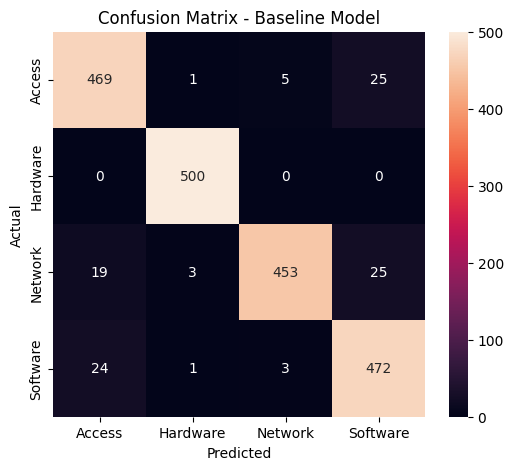

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=category_encoder.classes_,
            yticklabels=category_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
plt.show()